In [2]:
!rm -rf ~/.kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!pip install -q kaggle


In [4]:
!kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:04<00:00, 74.4MB/s]



In [5]:
import zipfile
zip=zipfile.ZipFile('/content/utkface-new.zip','r')
zip.extractall('/content')
zip.close()

In [14]:
import numpy as np
import pandas as pd
import os


In [18]:
import os

folder_path = "UTKFace"

age = []
gender = []
imgpath = []

for file in os.listdir(folder_path):

    age.append(int(file.split('_')[0]))

    gender.append(int(file.split('_')[1]))

    imgpath.append(os.path.join(file))

In [19]:
len(age)

23708

In [20]:
df=pd.DataFrame({'age':age,'gender':gender,'imgpath':imgpath})

In [21]:
df.shape

(23708, 3)

In [22]:
df.head()

,age,gender,imgpath
0,6,0,6_0_4_20161221202547897.jpg.chip.jpg
1,50,0,50_0_0_20170109011120677.jpg.chip.jpg
2,47,1,47_1_0_20170109220729248.jpg.chip.jpg
3,55,0,55_0_3_20170119205329112.jpg.chip.jpg
4,1,1,1_1_0_20170109190852630.jpg.chip.jpg


In [26]:
train_df=df.sample(frac=1,random_state=0).iloc[:20000]
test_df=df.sample(frac=1,random_state=0).iloc[20000:]

In [27]:
train_df.shape

(20000, 3)

In [28]:
test_df.shape

(3708, 3)

In [71]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=folder_path,
    x_col='imgpath',
    y_col=['age','gender'],
    target_size=(200,200),
     batch_size=32,
    class_mode='multi_output')


test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=folder_path,
    x_col='imgpath',
    y_col=['age','gender'],
    target_size=(200,200),
     batch_size=32,
    class_mode='multi_output')

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [72]:
from keras.applications.vgg16 import VGG16
from keras.layers import *
from keras.models import Model

In [73]:
vggnet=VGG16(input_shape=(200,200,3),include_top=False)

In [74]:
vggnet.trainable=False
output=vggnet.layers[-1].output
flatten=Flatten()(output)
dense1=Dense(512,activation='relu')(flatten)
dense2=Dense(256,activation='relu')(flatten)

dense3=Dense(512,activation='relu')(dense1)
dense4=Dense(512,activation='relu')(dense2)
output1=Dense(1,activation='linear',name='age')(dense3)
output2=Dense(1,activation='sigmoid',name='gender')(dense4)

In [75]:
model=Model(inputs=vggnet.input,outputs=[output1,output2])

In [76]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 200, 200,  │      1,792 │ input_layer_3[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 200, 200,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 100, 100,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 100, 100,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 100, 100,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 50, 50,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 50, 50,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 50, 50,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 50, 50,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 25, 25,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 25, 25,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 25, 25,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 25, 25,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 12, 12,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 12, 12,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 12, 12,    │  2,359,808 │ block5_conv1[0][

 Total params: 29,266,498 (111.64 MB)

 Trainable params: 14,551,810 (55.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

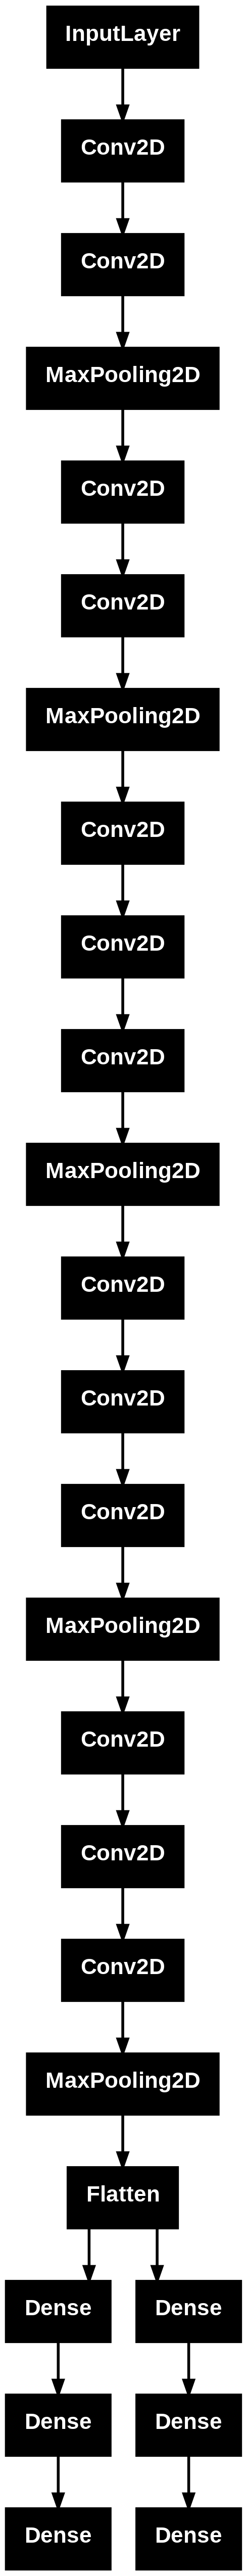

In [77]:
  from keras.utils import plot_model
  plot_model(model)

In [78]:
model.compile(

    optimizer='adam',

    loss=['mae', 'binary_crossentropy'],

    metrics=[['mae'], ['accuracy']]
)

In [79]:
model.fit(train_generator,epochs=10,validation_data=test_generator)

TypeError: `output_signature` must contain objects that are subclass of `tf.TypeSpec` but found <class 'list'> which is not.